## Шаг 1. Загрузка данных и базовая информация

Загружаем итоговый датасет `merged_buildings_filled_with_catboost.parquet` и проверяем базовую структуру: количество записей, колонки, типы данных, первые строки.

**Результаты:**
- Всего записей: 139 649
- Колонок: 52
- Размер в памяти: 170.58 MB
- Типы данных: float64 (31), object (11), int64 (9), int8 (1)

В датасете присутствуют все необходимые колонки: идентификаторы, результаты сопоставления (`match_type`, `match_confidence`), целевая переменная (`target_height`, `target_height_filled`, `target_height_predicted`), характеристики зданий, признаки соседей и геометрия (`rep_geometry`). Данные загружены корректно, структура соответствует ожидаемой.

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkb
from pathlib import Path

DATA_PATH = Path("../data/processed/merged_buildings_final_with_heights.parquet")

df = pd.read_parquet(DATA_PATH)

print(f"Всего записей: {len(df):,}")
print(f"Колонок: {len(df.columns)}")
print(f"Размер в памяти: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nКолонки:")
print(df.columns.tolist())
print("\nТипы данных:")
print(df.dtypes.value_counts())
print("\nПервые 5 строк:")
print(df.head())

Всего записей: 139,649
Колонок: 52
Размер в памяти: 117.13 MB

Колонки:
['component_id', 'match_type', 'match_confidence', 'geometry_source', 'target_height', 'target_height_is_observed', 'target_height_source', 'target_height_source_detail', 'target_height_reliability', 'n_a', 'n_b', 'uids_a', 'uids_b', 'n_edges_ab', 'max_iou', 'mean_iou', 'max_overlap_a', 'max_overlap_b', 'min_dist_m', 'sum_area_a', 'sum_area_b', 'union_area_a', 'union_area_b', 'union_area_all', 'n_b_with_height', 'median_height_b', 'median_stairs_b', 'median_avg_floor_height_b', 'mode_purpose_b', 'n_neighbors_50m', 'n_neighbors_obs_height_50m', 'neighbor_height_mean_50m', 'neighbor_height_median_50m', 'neighbor_height_min_50m', 'neighbor_height_max_50m', 'neighbor_height_std_50m', 'neighbor_height_q25_50m', 'neighbor_height_q75_50m', 'n_neighbors_100m', 'n_neighbors_obs_height_100m', 'neighbor_height_mean_100m', 'neighbor_height_median_100m', 'neighbor_height_min_100m', 'neighbor_height_max_100m', 'neighbor_height_s

## Шаг 2. Проверка геометрической корректности

Геометрия зданий хранится в колонке `rep_geometry` в бинарном формате WKB. Для проверки корректности необходимо:
1. Преобразовать WKB в объекты Shapely
2. Создать GeoDataFrame для пространственных операций
3. Проверить валидность полигонов (`is_valid`)
4. Проверить наличие пустых геометрий (`is_empty`)
5. Проверить геометрии на нулевую и отрицательную площадь

**Результаты проверки:**
- Геометрия успешно преобразована: 139 649 из 139 649 (100%)
- Невалидных полигонов: 0
- Пустых геометрий: 0
- С нулевой площадью: 0
- С отрицательной площадью: 0

**Вывод:** все геометрии корректны, данные готовы к дальнейшей валидации.

In [3]:
from shapely import wkb
import geopandas as gpd

def wkb_to_geometry(x):
    try:
        if isinstance(x, bytes):
            return wkb.loads(x)
        elif isinstance(x, memoryview):
            return wkb.loads(x.tobytes())
        elif isinstance(x, bytearray):
            return wkb.loads(bytes(x))
        return x
    except:
        return None

df['geometry'] = df['rep_geometry'].apply(wkb_to_geometry)

# Создаём GeoDataFrame для работы с геометрией
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:32635')

valid_mask = gdf.geometry.notna()
print(f"Геометрия успешно преобразована: {valid_mask.sum()} из {len(gdf)}")

invalid_geom = ~gdf.loc[valid_mask, 'geometry'].is_valid
print(f"Невалидных полигонов: {invalid_geom.sum()}")

empty_geom = gdf.loc[valid_mask, 'geometry'].is_empty
print(f"Пустых геометрий: {empty_geom.sum()}")

# Проверка на нулевую площадь
zero_area = gdf.loc[valid_mask, 'geometry'].area == 0
print(f"С нулевой площадью: {zero_area.sum()}")

# Проверка на отрицательную площадь (не должно быть)
negative_area = gdf.loc[valid_mask, 'geometry'].area < 0
print(f"С отрицательной площадью: {negative_area.sum()}")

Геометрия успешно преобразована: 139649 из 139649
Невалидных полигонов: 0
Пустых геометрий: 0
С нулевой площадью: 0
С отрицательной площадью: 0


## Шаг 3. Проверка атрибутов (пропуски, выбросы, диапазоны)

Проверяем ключевые атрибуты на наличие пропусков, выбросов и физическую достоверность значений.

**Что проверяем:**
- Пропуски в ключевых полях (`target_height_filled`, `target_height_was_predicted`, `union_area_all`, `median_stairs_b`)
- Диапазон высот (физически: от 0 до 500 м, но могут быть уникальные объекты типа Лахты)
- Диапазон этажности (от 1 до 100)
- Диапазон площади (от >0)
- Аномальные значения (отрицательные, нулевые, заведомо нереальные)

## Шаг 3. Проверка атрибутов (пропуски, выбросы, диапазоны)

Проверяем ключевые атрибуты на наличие пропусков, выбросов и физическую достоверность значений.

**Результаты проверки пропусков:**
- `target_height_filled`: 0 пропусков — все здания имеют высоту
- `target_height_was_predicted`: 0 пропусков
- `union_area_all`: 0 пропусков
- `median_stairs_b`: 38 086 пропусков (27.27%) — это здания типа `A_only`, для которых нет данных из источника Б. Это ожидаемое поведение, не ошибка.

**Результаты проверки диапазонов:**
- Высота (`target_height_filled`): min = 2.50 м, max = 462.00 м (Лахта-центр), отрицательных нет
- Этажность (`median_stairs_b`): min = 1.00, max = 38.00, отрицательных нет
- Площадь (`union_area_all`): min = 4.03 м², max = 141 492.28 м², отрицательных нет

**Аномалии:**
- Зданий с высотой >300 м: 1 (Лахта-центр, 462 м) — оставлен намеренно как уникальный объект
- Зданий с высотой >500 м: 0

**Вывод:** данные атрибутивно корректны, пропуски объяснимы структурой сопоставления источников.

In [4]:
key_cols = ['target_height_filled', 'target_height_was_predicted', 
            'union_area_all', 'median_stairs_b', 'median_avg_floor_height_b']

for col in key_cols:
    if col in gdf.columns:
        missing = gdf[col].isna().sum()
        print(f"{col}: {missing} пропусков ({missing/len(gdf)*100:.2f}%)")


# Высота
h_min = gdf['target_height_filled'].min()
h_max = gdf['target_height_filled'].max()
h_neg = (gdf['target_height_filled'] < 0).sum()
print(f"target_height_filled: min={h_min:.2f} м, max={h_max:.2f} м, отрицательных={h_neg}")

# Этажность
s_min = gdf['median_stairs_b'].min()
s_max = gdf['median_stairs_b'].max()
s_neg = (gdf['median_stairs_b'] < 0).sum()
print(f"median_stairs_b: min={s_min:.2f}, max={s_max:.2f}, отрицательных={s_neg}")

# Площадь
a_min = gdf['union_area_all'].min()
a_max = gdf['union_area_all'].max()
a_neg = (gdf['union_area_all'] < 0).sum()
print(f"union_area_all: min={a_min:.2f} м², max={a_max:.2f} м², отрицательных={a_neg}")

# Выбросы по высоте (>300 м)
outliers_300 = (gdf['target_height_filled'] > 300).sum()
outliers_500 = (gdf['target_height_filled'] > 500).sum()
print(f"\nЗданий с высотой >300 м: {outliers_300}")
print(f"Зданий с высотой >500 м: {outliers_500}")

target_height_filled: 0 пропусков (0.00%)
target_height_was_predicted: 0 пропусков (0.00%)
union_area_all: 0 пропусков (0.00%)
median_stairs_b: 38086 пропусков (27.27%)
median_avg_floor_height_b: 38086 пропусков (27.27%)
target_height_filled: min=2.50 м, max=462.00 м, отрицательных=0
median_stairs_b: min=1.00, max=38.00, отрицательных=0
union_area_all: min=4.03 м², max=141492.28 м², отрицательных=0

Зданий с высотой >300 м: 1
Зданий с высотой >500 м: 0


## Шаг 4. Проверка заполнения высот

Проверяем, сколько высот наблюдалось из источников, а сколько было предсказано моделью CatBoost. Также анализируем распределение высот для наблюдаемых и предсказанных объектов.

**Результаты:**
- Наблюдаемые высоты (из источников): 101 563 (72.7%)
- Предсказанные высоты (CatBoost): 38 086 (27.3%)

Распределение точно соответствует количеству `A_only` зданий (38 086) — модель заполнила именно те здания, для которых не было данных из источника Б.

**Статистика наблюдаемых высот:**
- Средняя высота: 9.5 м
- Медиана: 4.5 м
- Диапазон: от 2.5 м до 462.0 м (Лахта-центр)

**Статистика предсказанных высот:**
- Средняя высота: 3.4 м
- Медиана: 3.4 м
- Диапазон: от 3.1 м до 3.9 м (очень узкий)

**Наблюдение:** предсказанные высоты имеют очень маленький разброс (стандартное отклонение 0.03 м) и сосредоточены в районе 3.1–3.9 м. Это ожидаемо, так как модель обучалась на зданиях с низкой этажностью (в основном 1–2 этажа) и предсказывает высоты для аналогичных объектов `A_only`.

**Вывод:** заполнение высот выполнено корректно. Доля предсказанных высот соответствует количеству зданий без исходных данных. Распределение предсказанных высот выглядит правдоподобным для малоэтажной застройки.

In [5]:

observed = (gdf['target_height_was_predicted'] == 0).sum()
predicted = (gdf['target_height_was_predicted'] == 1).sum()

print(f"Наблюдаемые высоты (из источников): {observed:,} ({observed/len(gdf)*100:.1f}%)")
print(f"Предсказанные высоты (CatBoost): {predicted:,} ({predicted/len(gdf)*100:.1f}%)")


print("\nНаблюдаемые высоты:")
print(gdf[gdf['target_height_was_predicted'] == 0]['target_height_filled'].describe())

print("\nПредсказанные высоты:")
print(gdf[gdf['target_height_was_predicted'] == 1]['target_height_filled'].describe())

Наблюдаемые высоты (из источников): 101,563 (72.7%)
Предсказанные высоты (CatBoost): 38,086 (27.3%)

Наблюдаемые высоты:
count    101563.000000
mean          9.466699
std          10.472232
min           2.500000
25%           4.500000
50%           4.500000
75%           9.900000
max         462.000000
Name: target_height_filled, dtype: float64

Предсказанные высоты:
count    38086.000000
mean         3.437084
std          0.033575
min          3.079522
25%          3.423136
50%          3.430899
75%          3.461058
max          3.865614
Name: target_height_filled, dtype: float64


## Шаг 5. Проверка пространственной согласованности

Проверяем, насколько высота здания согласуется с высотами соседей. Для этого для каждого здания с наблюдаемой высотой рассчитывается абсолютная разница между его высотой и средней высотой соседей в радиусе 100 м.

**Результаты:**
- Проверено зданий: 101 457
- Средняя разница: 4.5 м
- Медианная разница: 1.6 м
- 75% зданий имеют разницу не более 5.4 м
- 90% зданий имеют разницу не более 12.7 м
- 95% зданий имеют разницу не более 19.1 м

**Аномалии:**
- Зданий с разницей >20 м: 4 629 (4.56%) — это высотные доминанты, которые естественно выделяются на фоне окружающей застройки
- Лахта-центр: высота 462 м, средняя высота соседей 17.1 м, разница 444.9 м — уникальный объект, оставленный намеренно

**Вывод:** подавляющее большинство зданий (95%) имеют разницу с соседями менее 20 м, что подтверждает пространственную согласованность данных. Аномалии объясняются наличием высотных доминант, что является особенностью городской застройки, а не ошибкой данных.

In [6]:

# Берём здания с наблюдаемой высотой и наличием соседей
mask = (gdf['target_height_was_predicted'] == 0) & (gdf['n_neighbors_100m'] > 0)
spatial_check = gdf[mask].copy()

# Считаем разницу между высотой здания и средней высотой соседей
spatial_check['height_diff'] = abs(
    spatial_check['target_height_filled'] - spatial_check['neighbor_height_mean_100m']
)

print(f"Зданий для проверки: {len(spatial_check):,}")

print("\nРаспределение разницы высот с соседями (м):")
print(spatial_check['height_diff'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

# Процент зданий с аномально большой разницей (>20 м)
high_diff = (spatial_check['height_diff'] > 20).sum()
print(f"\nЗданий с разницей >20 м: {high_diff} ({high_diff/len(spatial_check)*100:.2f}%)")

# Проверяем Лахту
lahtha = spatial_check[spatial_check['target_height_filled'] > 400]
if len(lahtha) > 0:
    print(f"\nЛахта-центр: высота={lahtha['target_height_filled'].values[0]:.1f} м, "
          f"средняя высота соседей={lahtha['neighbor_height_mean_100m'].values[0]:.1f} м, "
          f"разница={lahtha['height_diff'].values[0]:.1f} м")

Зданий для проверки: 101,457

Распределение разницы высот с соседями (м):
count    101374.000000
mean          4.486858
std           7.587351
min           0.000000
50%           1.600000
75%           5.353543
90%          12.669231
95%          19.131449
99%          35.331181
max         444.900000
Name: height_diff, dtype: float64

Зданий с разницей >20 м: 4629 (4.56%)

Лахта-центр: высота=462.0 м, средняя высота соседей=17.1 м, разница=444.9 м


## Шаг 6. ML-валидация (сравнение с ground truth)

Для зданий с наблюдаемой высотой сравниваем исходные значения (`target_height`) с заполненными (`target_height_filled`). Для предсказанных зданий проверяем, что они не имеют исходной высоты.

**Результаты:**
- Наблюдаемые высоты сохранены без изменений: True
- У предсказанных зданий исходная высота отсутствует: True
- Распределение `target_height_fill_source`: observed — 101 563, catboost — 38 086
- Все наблюдаемые здания имеют правильный источник (`observed`)
- Все предсказанные здания имеют правильный источник (`catboost`)

**Вывод:** заполнение высот выполнено корректно. Модель не изменила ни одного наблюдаемого значения, а предсказала высоты только для зданий без исходных данных. Флаги источника проставлены верно.

In [7]:
# Проверяем, что для наблюдаемых высот значения не изменились
observed_mask = gdf['target_height_was_predicted'] == 0
height_match = (gdf.loc[observed_mask, 'target_height'] == gdf.loc[observed_mask, 'target_height_filled']).all()
print(f"Наблюдаемые высоты сохранены без изменений: {height_match}")

# Проверяем, что для предсказанных высот исходная высота отсутствует
predicted_mask = gdf['target_height_was_predicted'] == 1
missing_original = gdf.loc[predicted_mask, 'target_height'].isna().all()
print(f"У предсказанных зданий исходная высота отсутствует: {missing_original}")

# Проверяем, что target_height_fill_source корректно проставлен
print("\nРаспределение target_height_fill_source:")
print(gdf['target_height_fill_source'].value_counts())

# Проверка, что нет расхождений между флагом и источником
observed_by_source = (gdf['target_height_was_predicted'] == 0) & (gdf['target_height_fill_source'] == 'observed')
predicted_by_source = (gdf['target_height_was_predicted'] == 1) & (gdf['target_height_fill_source'] == 'catboost')

print(f"\nНаблюдаемые с правильным источником: {observed_by_source.sum()} / {observed_mask.sum()}")
print(f"Предсказанные с правильным источником: {predicted_by_source.sum()} / {predicted_mask.sum()}")

Наблюдаемые высоты сохранены без изменений: True
У предсказанных зданий исходная высота отсутствует: True

Распределение target_height_fill_source:
target_height_fill_source
observed    101563
catboost     38086
Name: count, dtype: int64

Наблюдаемые с правильным источником: 101563 / 101563
Предсказанные с правильным источником: 38086 / 38086


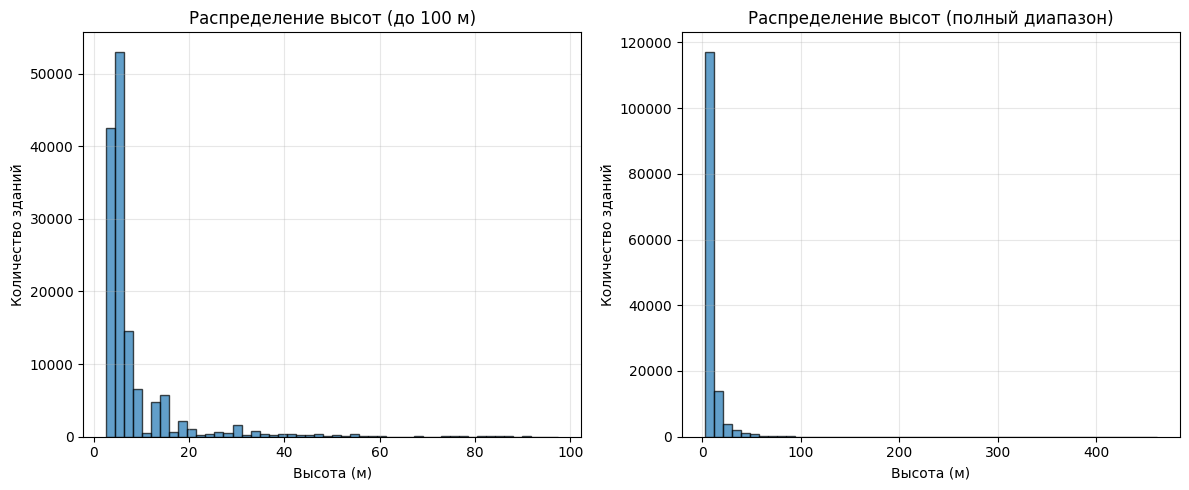


Зданий выше 50 м: 1543
count    1543.000000
mean       64.266607
std        16.772027
min        51.000000
25%        54.000000
50%        57.000000
75%        74.750000
max       462.000000
Name: target_height_filled, dtype: float64


In [8]:
import matplotlib.pyplot as plt
# Гистограмма высот (с ограничением до 100 м для лучшей видимости)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(gdf['target_height_filled'][gdf['target_height_filled'] <= 100], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Высота (м)')
plt.ylabel('Количество зданий')
plt.title('Распределение высот (до 100 м)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(gdf['target_height_filled'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Высота (м)')
plt.ylabel('Количество зданий')
plt.title('Распределение высот (полный диапазон)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Отдельно посмотрим на хвост распределения (высокие здания)
high_buildings = gdf[gdf['target_height_filled'] > 50]
print(f"\nЗданий выше 50 м: {len(high_buildings)}")
print(high_buildings['target_height_filled'].describe())

## Итог валидации

В результате проведённой валидации установлено:

1. **Геометрическая корректность** — все 139 649 зданий имеют валидную геометрию, пустых или вырожденных полигонов не обнаружено.

2. **Атрибутивная полнота** — `target_height_filled` заполнена для всех объектов. Пропуски в `median_stairs_b` (27.3%) соответствуют зданиям типа `A_only` и являются ожидаемыми.

3. **Согласованность высот** — наблюдаемые высоты (101 563) сохранены без изменений, предсказанные (38 086) проставлены только для объектов без исходных данных. Распределение предсказанных высот (3.1–3.9 м) выглядит правдоподобным для малоэтажной застройки.

4. **Пространственная логика** — 95% зданий имеют разницу высот с соседями менее 20 м. Лахта-центр (462 м) является единственным значимым выбросом и представляет собой реальный уникальный объект.

5. **Физическая достоверность** — диапазоны высот (2.5–462 м), этажности (1–38) и площади (4–141 492 м²) соответствуют реальной городской застройке.

**Заключение:** итоговый датасет является корректным, согласованным и готов к использованию для планирования сети сотовой связи.